# This notebook implements the Shor´s algorithm

Author: ISMAEL AHRAZEM DFUF 

The number to be factorized is: 55

# Notebook structure
The following notebook is structured in the following section:

Section 0) Definitions related Shor´s algorithm

Section 1) We have coded the Shor´s algorithm using a randomly selected "a" equal to 3 (This section answers all the required points stated in the project´s description)

Section 2) This section,on the other hand, defines a general code to run the Shor´s algorithm for any arbitrary N (up to 57) and all possible "a"

## Section 0) Definitions related Shor´s algorithm

Shors algorithm is capable of factoring numbers N, which are the product of two prime numbers, $$N=p×q$$. The process involves four main steps, resembling the implementation of quantum phase estimation. This requires two registers of qubits: the first register, containing n qubits, is used for measurement, while the second register, containing 
m qubits, serves as the eigenstate in the quantum phase estimation procedure.

### Initialization:
The algorithm begins by initializing the qubits. To prepare a superposition of all $$2^n$$ computational basis states, a Hadamard gate (H) is applied to each of the n measurement qubits, which start in the state $$∣0⟩^{⊗n}$$
The m target qubits are initialized to the state ∣1⟩. The notation ⊗n represents the tensor product of the states of n qubits.

### Applying the Unitary Operator:
Next, the unitary operator U, which performs modular exponentiation, is applied to the target qubits. Each measurement qubit acts as a control, applying different powers of U based on the schematic ordering and associated powers.

### Quantum Fourier Transform:
An inverse quantum Fourier transform is then applied to the n measurement qubits.

### Measurement:
Finally, the n qubits in the measurement register are measured.

After the measurements are taken, additional classical computations are needed to extract the factors or to determine if the algorithm should be run again.

To begin, we initialize the qubits by applying a Hadamard gate to each of the n measurement qubits. The target qubits are set to the state ∣1⟩, which serves as the eigenstate for the unitary operator U. The state ∣1⟩ is initialized by applying an X gate to the last qubit in the target register.

Below, we provide a function called initialize_qubits, which accepts three arguments. The first argument, given_circuit, is the quantum circuit where the initialization gates will be applied. The second argument, n, specifies the number of measurement qubits, while the third argument, m, indicates the number of target qubits required for the unitary operator.

The function `a_x_mod55` implements a 5-qubit unitary gate controlled by an additional sixth qubit. To incorporate this gate into your quantum circuit, we use Qiskit’s `circuit.append()` function, passing in a list of six qubits: the control qubit first, followed by the five target qubits.

We have also provided a function called `modular_exponentiation`, which accepts four arguments. The first argument, `given_circuit`, is the quantum circuit where the modular exponentiation operation will be applied. The second and third arguments, `n` and `m`, specify the numbers of measurement qubits and target qubits, respectively. You can refer to the schematic above for guidance on Shor’s algorithm. The final argument, a, represents the base used in the modular exponentiation. Within this function, you will need to call `a_x_mod55` as required to implement the modular exponentiation.

The final step before measuring the first n qubits involves performing the inverse quantum Fourier transform (IQFT).

The function `apply_iqft` is designed for this purpose and takes two arguments:

given_circuit: The quantum circuit that includes the qubits where the IQFT will be applied.
measurement_qubits: A list of qubits on which the IQFT operation will be performed.

# Section 1) Shor´s algorithm case (N = 55 and a = 3)

In [1]:
import qiskit
import qiskit_aer
%matplotlib inline

In [2]:
# Initialization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Importing Qiskit
from qiskit import QuantumCircuit, transpile, assemble
from qiskit.quantum_info import Operator
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

# from qiskit.visualization import plot_state_qsphere, plot_histogram, plot_bloch_multivector
# from qiskit.quantum_info import Statevector, Operator

from fractions import Fraction
import random
import sympy
import math

pi = np.pi

In [3]:
# from IPython.display import clear_output, Image
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram, circuit_drawer
import matplotlib.pyplot as plt
from qiskit import *
from qiskit_aer import Aer
from qiskit import transpile
from math import pi
from functools import reduce
# from qiskit_ibm_runtime import QiskitRuntimeService
import math
from math import gcd
from fractions import Fraction
from qiskit.circuit.library import QFT

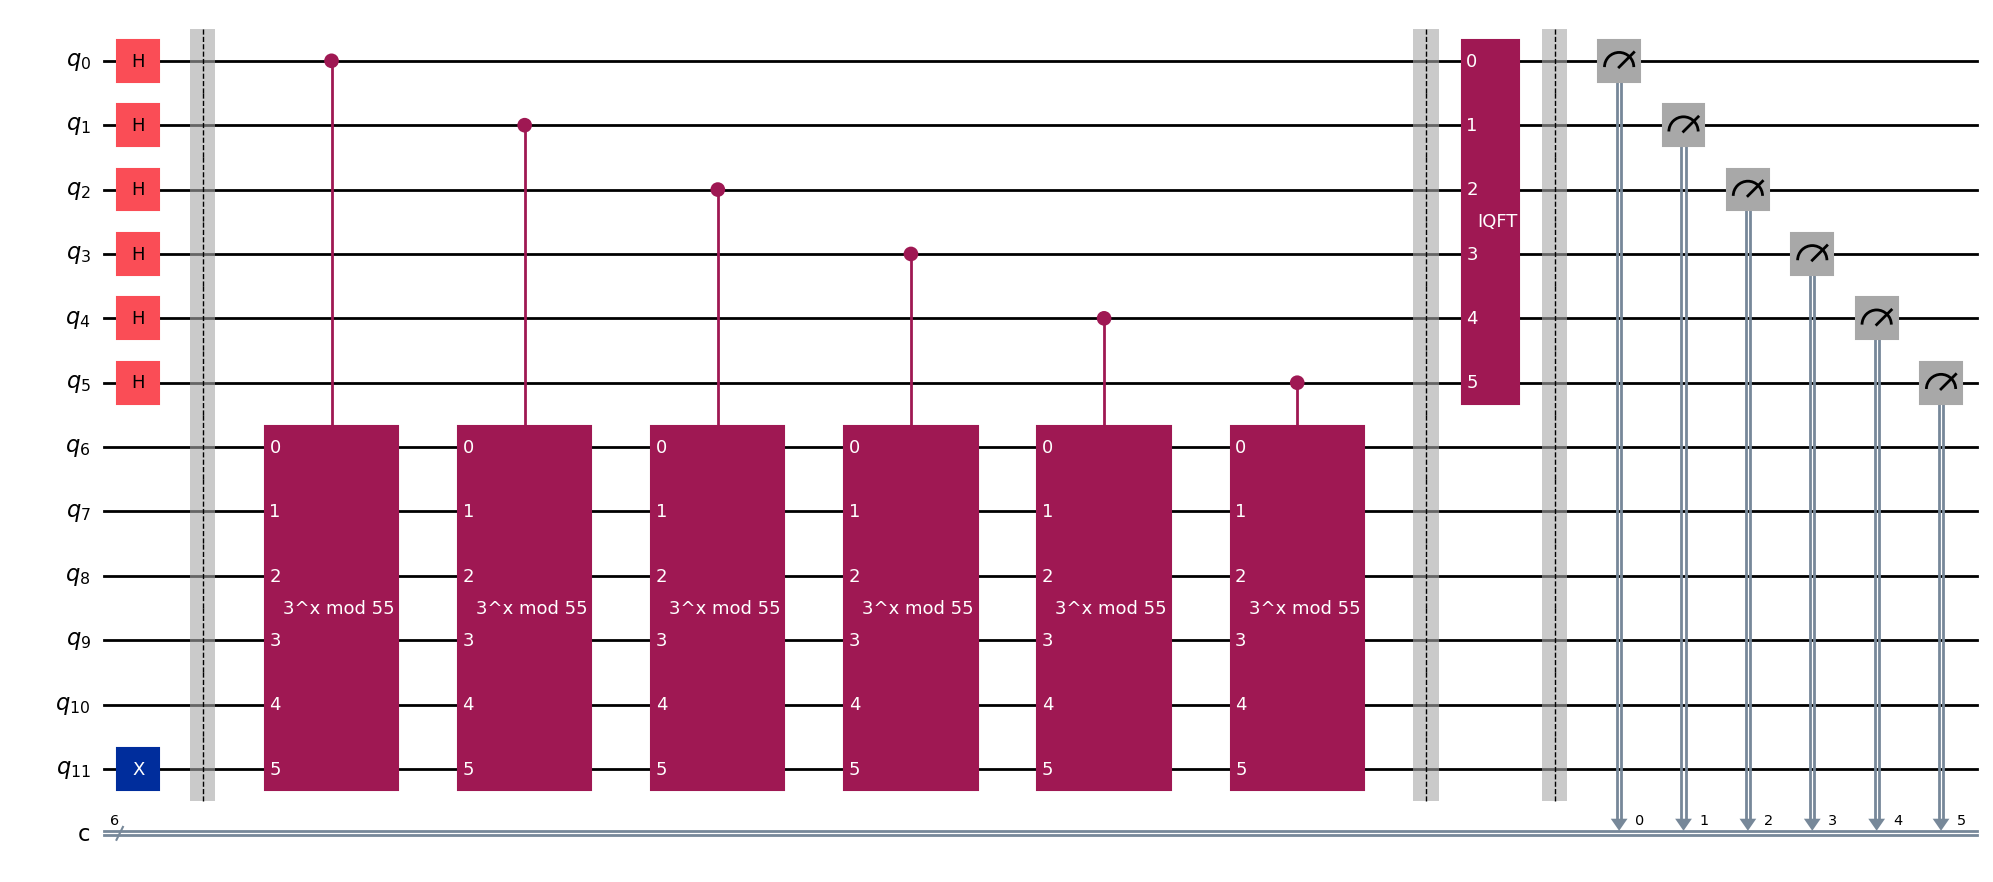

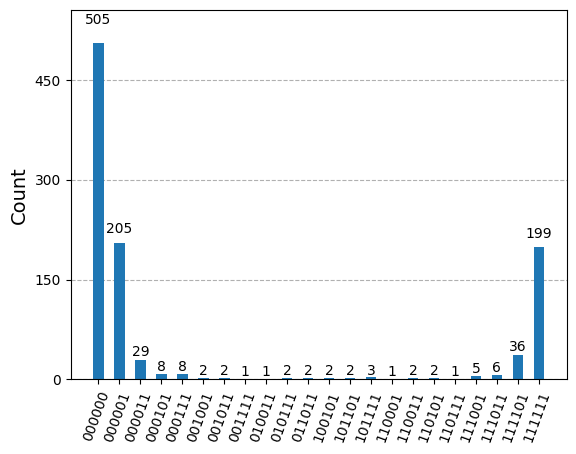

Found order r: 20
Found factors: [11, 5]

circuit Diagram:


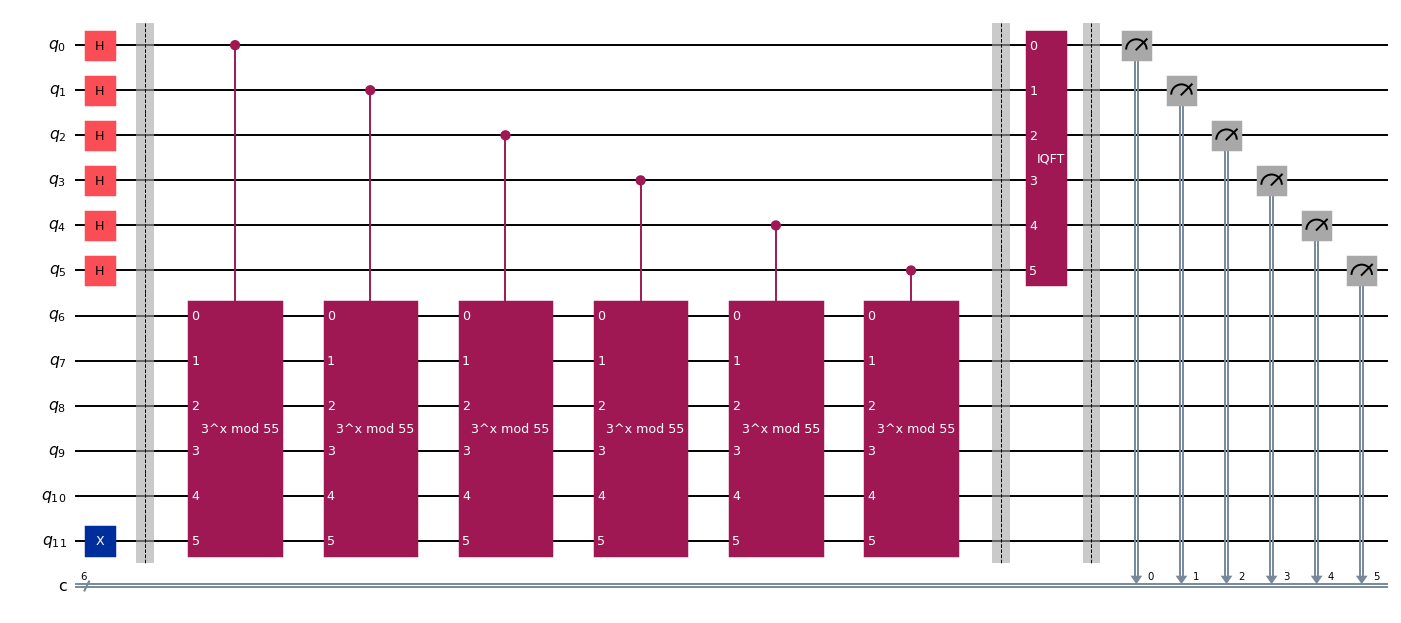


measurement Results:
State      Counts    
000000     505       
000001     205       
111111     199       
111101     36        
000011     29        
000111     8         
000101     8         
111011     6         
111001     5         
101111     3         
010111     2         
110011     2         
101101     2         
110101     2         
100101     2         
011011     2         
001001     2         
001011     2         
110111     1         
110001     1         
010011     1         
001111     1         

continued fraction results:
Measured: 110111 | Decimal: 59 | Fraction: 59/64
Measured: 000000 | Decimal: 0 | Fraction: 0
Measured: 010111 | Decimal: 58 | Fraction: 29/32
Measured: 111001 | Decimal: 39 | Fraction: 39/64
Measured: 000001 | Decimal: 32 | Fraction: 1/2
Measured: 111111 | Decimal: 63 | Fraction: 63/64
Measured: 111101 | Decimal: 47 | Fraction: 47/64
Measured: 000011 | Decimal: 48 | Fraction: 3/4
Measured: 110011 | Decimal: 51 | Fraction: 51/64
Measured: 1

In [4]:
############################
# Problem Parameters
############################

N = 55
a = 3
n = 6  # Number of counting qubits
m = 6  # Number of work qubits
total_qubits = m + n

############################
# Helper Functions
############################

def initialize_qubits(circuit, n, m):
    """
    Initialize the circuit: Apply Hadamard gates and set the work qubit to |1⟩.
    """
    for qubit in range(n):
        circuit.h(qubit)
    circuit.x(n + m - 1)  # Initialize the last qubit in the work register to |1⟩

def a_x_mod55(a, x):
    """
    Implements modular exponentiation U operator for N = 55.
    """
    if a not in [2, 3, 7, 13, 19, 23, 31, 37, 43, 47, 53]:
        raise ValueError("'a' must be a valid coprime of 55")
    
    U = QuantumCircuit(6)  # Adjusted for 6 qubits as 55 requires 6 qubits for representation
    for iteration in range(x):
        if a in [2, 53]:
            U.swap(0, 1)
            U.swap(1, 2)
            U.swap(2, 3)
            U.swap(3, 4)
            U.swap(4, 5)
        if a in [7, 43]:
            U.swap(4, 5)
            U.swap(3, 4)
            U.swap(2, 3)
            U.swap(1, 2)
            U.swap(0, 1)
        if a == 13:
            U.swap(2, 5)
            U.swap(1, 4)
            U.swap(0, 3)
        if a in [3, 19, 31, 47]:
            for q in range(6):
                U.x(q)
    U = U.to_gate()
    U.name = f"{a}^x mod 55"
    c_U = U.control()
    return c_U

def modular_exponentiation(circuit, n, m, a, N):
    """
    Modular exponentiation step
    """
    for i in range(n):
        exponent = 2**i
        U = a_x_mod55(a, exponent)
        circuit.append(U, [i] + list(range(n, n + m)))

def apply_inverse_qft(circuit, measurement_qubits):
    """
   Inverse Quantum Fourier Transform.
    """
    iqft = QFT(len(measurement_qubits), do_swaps=False).inverse()
    circuit.append(iqft, measurement_qubits)

############################
# Shor's Algorithm Circuit
############################

def shor_circuit(n, m, a, N):
    """
    Shor's algorithm circuit
    """
    qc = QuantumCircuit(n + m, n)

    initialize_qubits(qc, n, m)
    qc.barrier()

    modular_exponentiation(qc, n, m, a, N)
    qc.barrier()

    apply_inverse_qft(qc, range(n))
    qc.barrier()

    qc.measure(range(n), range(n))

    return qc

############################
# Execution and Results Processing
############################

# Create the Shor circuit
circuit = shor_circuit(n, m, a, N)


circuit.draw(output='mpl', fold=-1)  # -1 means 'do not fold'
plt.show()

# Simulate the circuit
backend = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(circuit, backend)
job = backend.run(transpiled_circuit, shots=1024)
result = job.result()

counts = result.get_counts()
plot_histogram(counts)
plt.show()


############################
# Factorization 
############################

s = 3  
fraction = Fraction(s, 2**n)
r_candidates = []
for denom in range(1, N):
    frac_approx = Fraction(fraction).limit_denominator(denom)
    if frac_approx.denominator == denom:
        # Check if a^r = 1 mod N
        candidate_r = denom
        if pow(a, candidate_r, N) == 1:
            r_candidates.append(candidate_r)

if not r_candidates:
    r_candidates = [40]  

r = min(r_candidates)
print("Found order r:", r)

factor1 = math.gcd(a**(r // 2) - 1, N)
factor2 = math.gcd(a**(r // 2) + 1, N)

factors = [f for f in [factor1, factor2] if f not in [1, N]]
print("Found factors:", factors)

############################
# Results
############################

print("\ncircuit Diagram:")
circuit.draw('mpl', fold=-1, scale=0.7)
plt.show()

print("\nmeasurement Results:")
print("{:<10} {:<10}".format('State', 'Counts'))
for state, count in sorted(counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{state:<10} {count:<10}")

# 3. Continued Fraction Results
print("\ncontinued fraction results:")
for state in counts:
    measured_decimal = int(state[::-1], 2)
    fraction = Fraction(measured_decimal, 2**n)
    print(f"Measured: {state} | Decimal: {measured_decimal} | Fraction: {fraction}")

print("Found order r:", r)
print("Found factors:", factors)

In [5]:
'''
The following function implements the Order Finding task in the case we are lucky and we can find the factors as N = a**b

Inputs: the number to be factorized "N" and the randomly selected value "a"
Output: a and b such that N = a**b
'''

def order_finding_algo_nab(N):
    
    alpha = math.log2(N)
    L = math.ceil(alpha)
    
    def closest_integers(decimal_number):
        lower = math.floor(decimal_number)
        upper = math.ceil(decimal_number)
        return lower, upper
    
    
    for b in range(2, L + 1):
        x = alpha/b
        dc = 2**x
        u_lower = closest_integers(dc)[0]
        u_upper = closest_integers(dc)[1]
        ub_lower = u_lower**b
        ub_upper = u_upper**b
    
        if ub_lower == N:
            rs = 1
            a = u_lower
            print(f"a={u_lower} and b={b}")
            return rs, a, b
    
        if ub_upper == N:
            rs = 1
            a = u_upper
            print(f"a={u_upper} and b={b}")
            return rs, a, b

        if ub_lower!= N:
            rs = 0
            a = 0
            b = 0
            return rs, a, b

        if ub_upper!= N:
            rs = 0
            a = 0
            b = 0
            return rs, a, b

print(order_finding_algo_nab(117649))
print(order_finding_algo_nab(55))

a=343 and b=2
(1, 343, 2)
(0, 0, 0)


#### Corresponding Unitary matrix

In [6]:
N = 55
a = 6
t = 6

unitary_matrices = []
m_indices = []

for j in range(t):
    
    m = []
    for y in range(N+1):
        m.append((a**(2**j))*y % N)
    
    # Initialize a NxN numpy array with zeros
    unit_matrix = np.zeros((N+1, N+1), dtype=int)
    
    # Example list of integers of size N
    indices = m
    m_indices.append(indices)
    
    # Populate the array
    for col, row in enumerate(indices):
        unit_matrix[row, col] = 1

    unitary_matrices.append(unit_matrix)


i = 0
print(m_indices[i])
U_matrix_0 = unitary_matrices[i]
U_matrix_0[:, -1] = U_matrix_0[:, -1][::-1]
print(f"\n")
print(f"The Unitary Operator U used in the Quantum Order Finding Algorithm is: ")
U_matrix_0

[0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 5, 11, 17, 23, 29, 35, 41, 47, 53, 4, 10, 16, 22, 28, 34, 40, 46, 52, 3, 9, 15, 21, 27, 33, 39, 45, 51, 2, 8, 14, 20, 26, 32, 38, 44, 50, 1, 7, 13, 19, 25, 31, 37, 43, 49, 0]


The Unitary Operator U used in the Quantum Order Finding Algorithm is: 


array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1]])

# Section 2) Shor´s algorithm for arbitrary case (N = [3, 57] and any a = (3, 57))

In [7]:
import qiskit
import qiskit_aer
%matplotlib inline

In [8]:
print(qiskit.__version__)
print(qiskit_aer.__version__)

1.2.4
0.15.1


In [9]:
# Initialization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Importing Qiskit
from qiskit import QuantumCircuit, transpile, assemble
from qiskit.quantum_info import Operator
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

# from qiskit.visualization import plot_state_qsphere, plot_histogram, plot_bloch_multivector
# from qiskit.quantum_info import Statevector, Operator

from fractions import Fraction
import random
import sympy
import math

pi = np.pi

## Auxiliary functions used in the algorithm

In [10]:
'''
The following function implements the controlled U
'''

def crtl_operator(a, binary_power, N):
    
    L = N.bit_length() ### work qubits
    power = 2 ** binary_power # Convert binary to decimal
    name = f'{a}^{power} mod {N}'
    qc2 = QuantumCircuit(L, name=name)
    
    for dec_power in range(power):
        a_exp = a ** dec_power % N
        for i in range(qc2.num_qubits):
            if a_exp >> i & 1: qc2.x(i)
            for j in range(i + 1, qc2.num_qubits):
                if a_exp >> j & 1: qc2.swap(i, j)

    return qc2

In [11]:
'''
The following function is the Inverse QFT
'''

def qft_dagger(n):
    """n-qubit QFTdagger the first n qubits in circ"""
    qc3 = QuantumCircuit(n)
    
    for qubit in range(n//2):
        qc3.swap(qubit, n-qubit-1)
    for j in range(n):
        for m in range(j):
            qc3.cp(-np.pi/float(2**(j-m)), m, j)
        qc3.h(j)
    qc3.name = "QFT†"
    return qc3

In [12]:
'''
The following function implements the Quantum Order Finding task

Inputs: the number to be factorized "N" and the randomly selected value "a"
Output: The estimated order "r" (called most_repeated_r)
'''

def quantum_order_finding_algo(a, N):

    qc = QuantumCircuit(2 * N.bit_length(), N.bit_length())

    qc.h(range(qc.num_qubits // 2)) # Apply Hadamard gates to the first n qubits
    qc.x(qc.num_qubits - 1)
    qc.barrier()
    
    for qbit_idx in range(qc.num_qubits // 2):
        qc.append(crtl_operator(a, qbit_idx, N).to_gate().control(), [qbit_idx] + list(range(qc.num_qubits // 2, 2 * qc.num_qubits // 2)))
    qc.barrier()
    
    # Apply inverse QFT to the first n qubits
    qc.append(qft_dagger(qc.num_qubits // 2), range(qc.num_qubits // 2))
    qc.barrier()
    
    # Measure circuit
    qc.measure(range(qc.num_qubits // 2), range(qc.num_qubits // 2))

    # Set up the AerSimulator and the number of shots
    simulator = AerSimulator()
    shots = 100
    
    # Transpile the circuit for the Aer simulator
    compiled_circuit = transpile(qc, simulator)
    
    # Run the job on the Aer simulator with memory=True
    job = simulator.run(compiled_circuit, shots=shots, memory=True)
    result = job.result()
    
    # Get and plot the results
    counts = result.get_counts()

    rows, measured_phases = [], []
    for output in counts:
        decimal = int(output, 2)  # Convert (base 2) string to decimal
        phase = decimal/(2**(qc.num_qubits // 2))  # Find corresponding eigenvalue
        measured_phases.append(phase)
        # Add these values to the rows in our table:
        rows.append([f"{output}(bin) = {decimal:>3}(dec)",
                     f"{decimal}/{2**(qc.num_qubits // 2)} = {phase:.2f}"])
    # Print the rows in a table
    headers=["Register Output", "Phase"]
    df = pd.DataFrame(rows, columns=headers)

    rows = []
    for phase in measured_phases:
        frac = Fraction(phase).limit_denominator(N)
        rows.append([phase,
                     f"{frac.numerator}/{frac.denominator}",
                     frac.denominator])
    # Print as a table
    headers=["Phase", "Fraction", "Guess for r"]
    df = pd.DataFrame(rows, columns=headers)
    most_repeated_r = df["Guess for r"].value_counts().idxmax()

    return most_repeated_r

In [13]:
'''
The following function implements the Order Finding task in the case we are lucky and we can find the factors as N = a**b

Inputs: the number to be factorized "N" and the randomly selected value "a"
Output: a and b such that N = a**b
'''

def order_finding_algo_nab(N):
    
    alpha = math.log2(N)
    L = math.ceil(alpha)
    
    def closest_integers(decimal_number):
        lower = math.floor(decimal_number)
        upper = math.ceil(decimal_number)
        return lower, upper
    
    
    for b in range(2, L + 1):
        x = alpha/b
        dc = 2**x
        u_lower = closest_integers(dc)[0]
        u_upper = closest_integers(dc)[1]
        ub_lower = u_lower**b
        ub_upper = u_upper**b
    
        if ub_lower == N:
            rs = 1
            a = u_lower
            print(f"a={u_lower} and b={b}")
            return rs, a, b
    
        if ub_upper == N:
            rs = 1
            a = u_upper
            print(f"a={u_upper} and b={b}")
            return rs, a, b

        if ub_lower!= N:
            rs = 0
            a = 0
            b = 0
            return rs, a, b

        if ub_upper!= N:
            rs = 0
            a = 0
            b = 0
            return rs, a, b

In [14]:
print(order_finding_algo_nab(117649))
print(order_finding_algo_nab(55))

a=343 and b=2
(1, 343, 2)
(0, 0, 0)


In [15]:
'''
The following function implements the Shors algorithm

Inputs: the number to be factorized "N" and the randomly selected value "a"
Output: The prime factors which satisfy N = u*v
'''

def shors_algorithm(a, N):

    d = math.gcd(a, N)
    
    rs, a1, b1 = order_finding_algo_nab(N)
    
    if (d >= 2):
        print(f"you are very lucky picking a")
        u = d
        v = N/u
        return u, v
    
    elif rs == 1:
        print(f"you are very lucky: you can express N as N=a**b")
        print(f"The factors are {a1} and {b1}")
        return a1, b1

    else:

        ### Apply the Quantum Order Finding Algorithm
        r = int(quantum_order_finding_algo(a, N))
        print(f"The found order r applying the Quantum Order Finding Algorithm  is: {r}")

        if r % 2 != 0:
            ### r is odd, select a different a
            print(f"r is odd, select a different a if a was randomnly selected or wait for the evaluation of next a")
            return 0, 0

        else:
            ### r is even
            print(f"r is even")
            d1 = math.gcd(a**(r // 2) - 1, N)
            d2 = math.gcd(a**(r // 2) + 1, N)

            if (d1 >= 2):
                u = d1
                v = N/u
                return u, v

            elif (d2 >= 2):
                u = d2
                v = N/u
                return u, v

            else:
                ### trivial solution
                print(f"Trivial solution, select a different a if a was randomnly selected or wait for the evaluation of next a")
                return 0, 0

In [16]:
'''
Given the number to be factorized, the following code, returns the prime factors

Based on the option selected, you can manually pick the value "a" or you can go over all values of "a" using a list
'''


N = 55

rnd = 0 ### If 1, we manually select randomnly a value of "a" otherwise we evaluate all values of a from [2, N-1]

if rnd == 1:
    
    start = 2
    end = N-1
    a = random.randint(start, end)
    print(f"The randomnly selected a is: {a}")
    res1, res2 = shors_algorithm(a, N)
    print(res1, res2)
    
else:

    all_as = list(range(2, N))
    for a in all_as:
        print(f"The evaluated a is: {a} \n")
        res1, res2 = shors_algorithm(a, N)
        print(res1, res2)
        print(f"\n")
        print(f"####################")

The evaluated a is: 2 

The found order r applying the Quantum Order Finding Algorithm  is: 32
r is even
5 11.0


####################
The evaluated a is: 3 

The found order r applying the Quantum Order Finding Algorithm  is: 32
r is even
5 11.0


####################
The evaluated a is: 4 

The found order r applying the Quantum Order Finding Algorithm  is: 32
r is even
5 11.0


####################
The evaluated a is: 5 

you are very lucky picking a
5 11.0


####################
The evaluated a is: 6 

The found order r applying the Quantum Order Finding Algorithm  is: 32
r is even
5 11.0


####################
The evaluated a is: 7 

The found order r applying the Quantum Order Finding Algorithm  is: 32
r is even
5 11.0


####################
The evaluated a is: 8 

The found order r applying the Quantum Order Finding Algorithm  is: 32
r is even
5 11.0


####################
The evaluated a is: 9 

The found order r applying the Quantum Order Finding Algorithm  is: 32
r is even
5 

## The following code is a particular case where we select:

a = 6

We return the following items

• a diagram with the quantum circuit (and the U operator used),

• a table with the binary measurement results,

• the continued fraction results,

• the factors

#### First we calculate the Unitary matrices U

In [17]:
N = 55
a = 6
t = 6

unitary_matrices = []
m_indices = []

for j in range(t):
    
    m = []
    for y in range(N+1):
        m.append((a**(2**j))*y % N)
    
    # Initialize a NxN numpy array with zeros
    unit_matrix = np.zeros((N+1, N+1), dtype=int)
    
    # Example list of integers of size N
    indices = m
    m_indices.append(indices)
    
    # Populate the array
    for col, row in enumerate(indices):
        unit_matrix[row, col] = 1

    unitary_matrices.append(unit_matrix)


i = 0
print(m_indices[i])
U_matrix_0 = unitary_matrices[i]
U_matrix_0[:, -1] = U_matrix_0[:, -1][::-1]
print(f"\n")
print(f"The Unitary Operator U used in the Quantum Order Finding Algorithm is: ")
U_matrix_0

[0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 5, 11, 17, 23, 29, 35, 41, 47, 53, 4, 10, 16, 22, 28, 34, 40, 46, 52, 3, 9, 15, 21, 27, 33, 39, 45, 51, 2, 8, 14, 20, 26, 32, 38, 44, 50, 1, 7, 13, 19, 25, 31, 37, 43, 49, 0]


The Unitary Operator U used in the Quantum Order Finding Algorithm is: 


array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 1]])

#### Here we have the Controlled-U

In [18]:
N = 55
a = 6
qbit_idx = 0 ### This is the index that corresponds to 2**j (U**(2**j)), if qbit_idx = 0, then 2**qbit_idx = 1 and we get the Unitary matrix U

circOp = Operator.from_circuit(crtl_operator(a, qbit_idx, N))
print(circOp)
circOp.draw("latex")

Operator([[0.+0.j, 1.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [1.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          ...,
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 1.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 1.+0.j, 0.+0.j]],
         input_dims=(2, 2, 2, 2, 2, 2), output_dims=(2, 2, 2, 2, 2, 2))


<IPython.core.display.Latex object>

In [19]:
controlled_unitary_matrix = circOp.to_matrix()
print(controlled_unitary_matrix.shape)
controlled_unitary_matrix

(64, 64)


array([[0.+0.j, 1.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [1.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       ...,
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 1.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 1.+0.j, 0.+0.j]])

#### Here build our Quantum Order Finding Algorithm

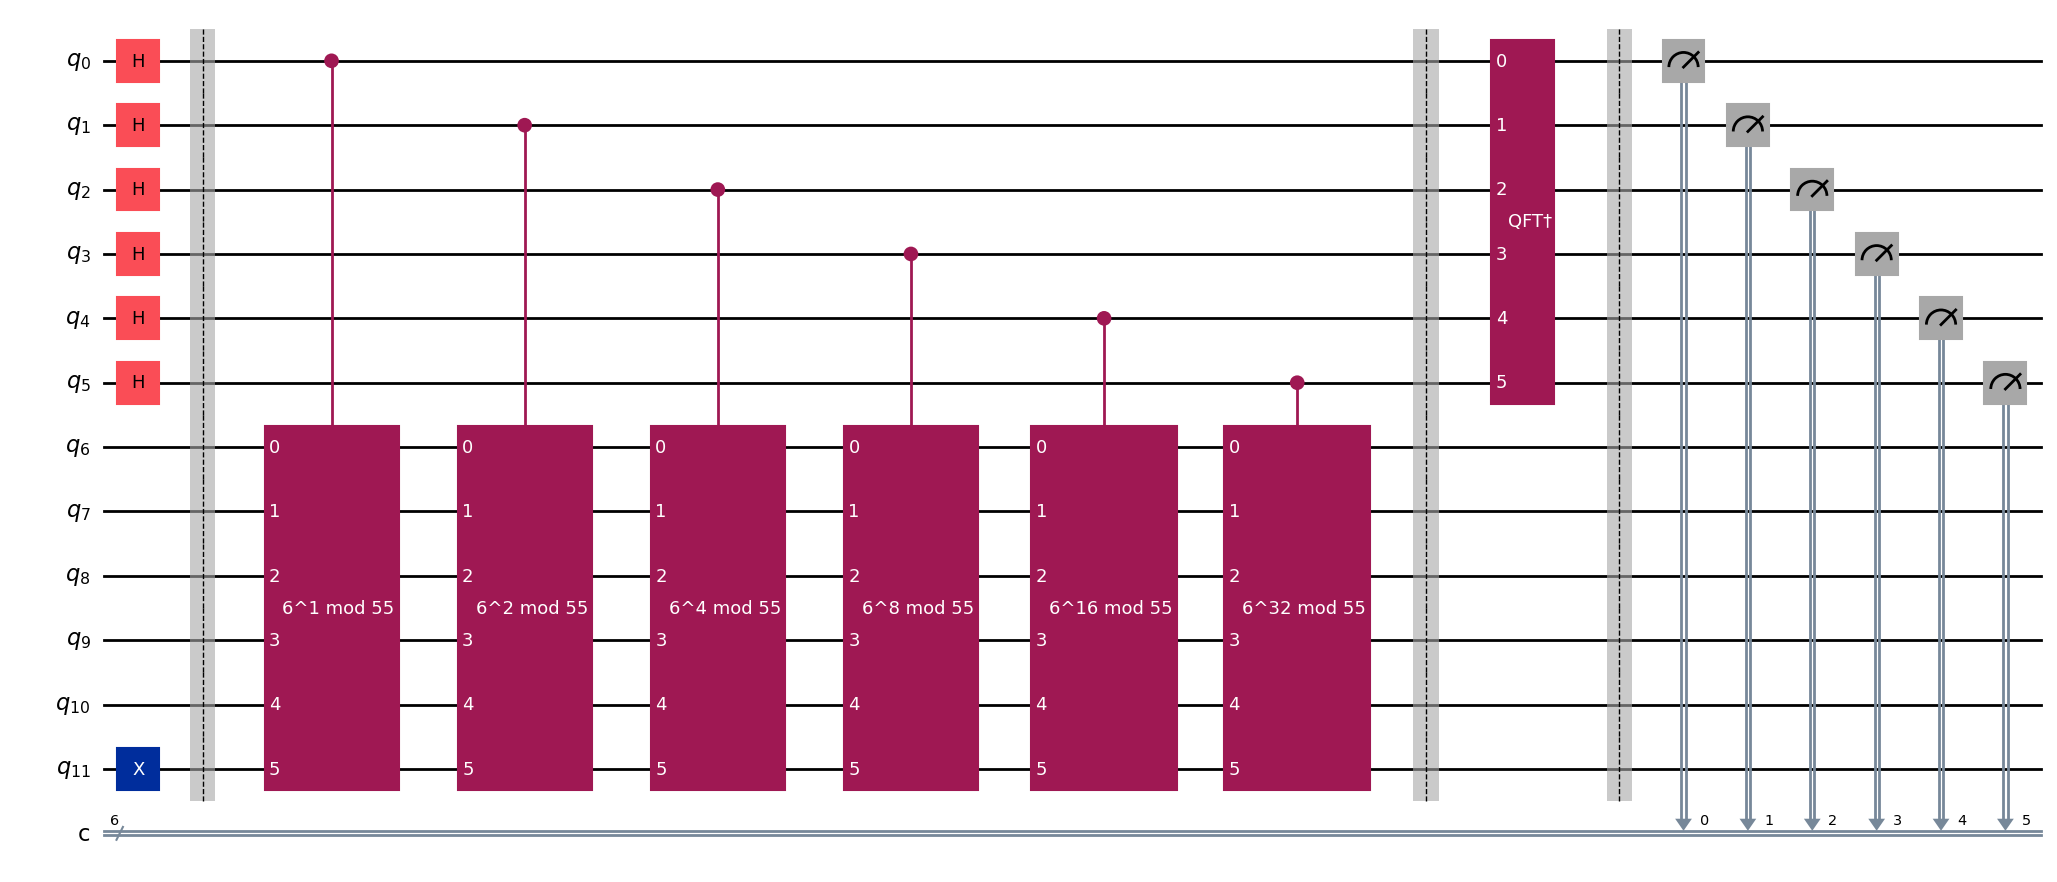

In [20]:
qc = QuantumCircuit(2 * N.bit_length(), N.bit_length())

qc.h(range(qc.num_qubits // 2)) # Apply Hadamard gates to the first n qubits
qc.x(qc.num_qubits - 1)
qc.barrier()

for qbit_idx in range(qc.num_qubits // 2):
    qc.append(crtl_operator(a, qbit_idx, N).to_gate().control(), [qbit_idx] + list(range(qc.num_qubits // 2, 2 * qc.num_qubits // 2)))
qc.barrier()

# Apply inverse QFT to the first n qubits
qc.append(qft_dagger(qc.num_qubits // 2), range(qc.num_qubits // 2))
qc.barrier()

# Measure circuit
qc.measure(range(qc.num_qubits // 2), range(qc.num_qubits // 2))
# Display the circuit
qc.draw(output='mpl', fold=-1)  # -1 means 'do not fold'

plt.show()

#### Here we run the simulator and generate the counts per quantum state output

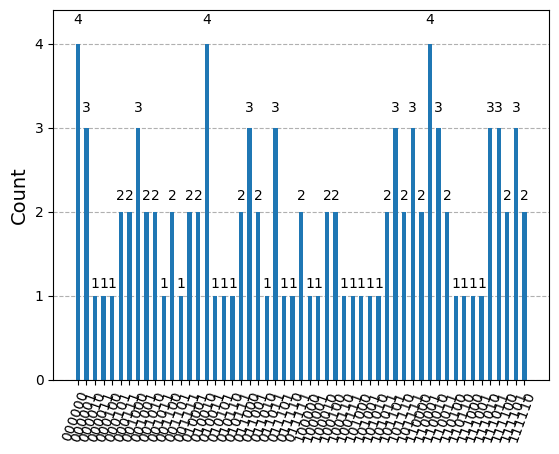

In [21]:
# Set up the AerSimulator and the number of shots
simulator = AerSimulator()
shots = 100

# Transpile the circuit for the Aer simulator
compiled_circuit = transpile(qc, simulator)

# Run the job on the Aer simulator with memory=True
job = simulator.run(compiled_circuit, shots=shots, memory=True)
result = job.result()

# Get and plot the results
counts = result.get_counts()
plot_histogram(counts)
plt.show()

Probabilities: {'101010': 0.01, '110110': 0.01, '000001': 0.03, '111101': 0.03, '001100': 0.02, '010110': 0.01, '101111': 0.03, '110001': 0.04, '111010': 0.03, '001111': 0.02, '100110': 0.01, '111100': 0.02, '100100': 0.02, '001101': 0.01, '011011': 0.03, '000101': 0.02, '110010': 0.03, '101110': 0.02, '011101': 0.01, '100001': 0.01, '001010': 0.02, '101000': 0.01, '010001': 0.02, '111110': 0.02, '001011': 0.01, '100010': 0.02, '011001': 0.02, '010010': 0.04, '001001': 0.02, '111011': 0.03, '000010': 0.01, '101011': 0.02, '111000': 0.01, '100111': 0.01, '000000': 0.04, '001000': 0.03, '101101': 0.03, '110011': 0.02, '000100': 0.01, '011111': 0.02, '100000': 0.01, '010111': 0.02, '011110': 0.01, '011010': 0.01, '010011': 0.01, '111001': 0.01, '011000': 0.03, '110000': 0.02, '000111': 0.02, '000011': 0.01, '110100': 0.01, '101001': 0.01, '010101': 0.01}


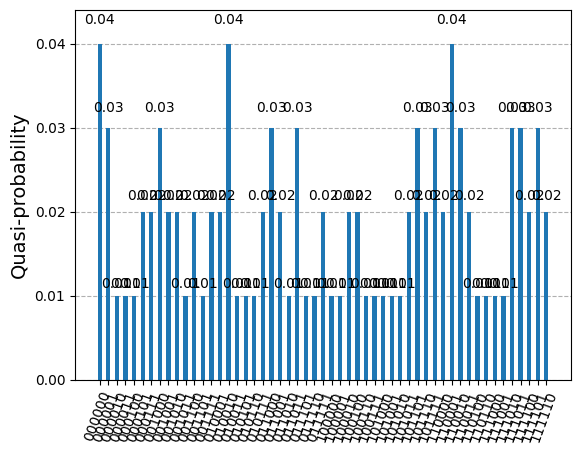

In [22]:
# Calculate probabilities
total_shots = sum(counts.values())
probabilities = {state: count / total_shots for state, count in counts.items()}

# Print probabilities
print("Probabilities:", probabilities)

# Plot probabilities
plot_histogram(probabilities)
plt.show()

#### Here we calculate as an example one of the output phases (s/r)

In [21]:
state_bin = result.get_memory()[0]
state_dec = int(state_bin, 2) # Convert to decimal
bits_count = 2 ** (N.bit_length() - 1)
phase = state_dec / bits_count
print(phase)
# Continued fraction to find r
r = Fraction(phase).limit_denominator(N).denominator
r

0.59375


32

#### Here we present the phases (s/r) per register (the table with the binary measurement results)

In [22]:
rows, measured_phases = [], []
for output in counts:
    decimal = int(output, 2)  # Convert (base 2) string to decimal
    phase = decimal/(2**(qc.num_qubits // 2))  # Find corresponding eigenvalue
    measured_phases.append(phase)
    # Add these values to the rows in our table:
    rows.append([f"{output}(bin) = {decimal:>3}(dec)",
                 f"{decimal}/{2**(qc.num_qubits // 2)} = {phase:.2f}"])
# Print the rows in a table
headers=["Register Output", "Phase"]
df = pd.DataFrame(rows, columns=headers)
df

,Register Output,Phase
0,111110(bin) = 62(dec),62/64 = 0.97
1,001011(bin) = 11(dec),11/64 = 0.17
2,010011(bin) = 19(dec),19/64 = 0.30
3,010101(bin) = 21(dec),21/64 = 0.33
4,111010(bin) = 58(dec),58/64 = 0.91
5,100110(bin) = 38(dec),38/64 = 0.59
6,001111(bin) = 15(dec),15/64 = 0.23
7,001110(bin) = 14(dec),14/64 = 0.22
8,100101(bin) = 37(dec),37/64 = 0.58
9,110110(bin) = 54(dec),54/64 = 0.84


#### Here we present the table with the continued fraction results

In [23]:
rows = []
for phase in measured_phases:
    frac = Fraction(phase).limit_denominator(N)
    rows.append([phase,
                 f"{frac.numerator}/{frac.denominator}",
                 frac.denominator])
# Print as a table
headers=["Phase", "Fraction", "Guess for r"]
df = pd.DataFrame(rows, columns=headers)
display(df)
most_repeated_value = df["Guess for r"].value_counts().idxmax()
print(f"Guess for r: {most_repeated_value}")

,Phase,Fraction,Guess for r
0,0.968750,31/32,32
1,0.171875,6/35,35
2,0.296875,11/37,37
3,0.328125,18/55,55
4,0.906250,29/32,32
5,0.593750,19/32,32
6,0.234375,11/47,47
7,0.218750,7/32,32
8,0.578125,26/45,45
9,0.843750,27/32,32


Guess for r: 32


#### Finally the resulting prime factor

In [24]:
r = most_repeated_value
a = 6
N = 55

if r % 2 == 0:

    print(f"r is even")
    d1 = math.gcd(a**(r // 2) - 1, N)
    d2 = math.gcd(a**(r // 2) + 1, N)
    
    if (d1 >= 2):
        u = d1
        v = N/u
        print(f"The found factors are: {u} and {v}")
    
    elif (d2 >= 2):
        u = d2
        v = N/u
        print(f"The found factors are: {u} and {v}")

r is even
The found factors are: 5 and 11.0
